In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


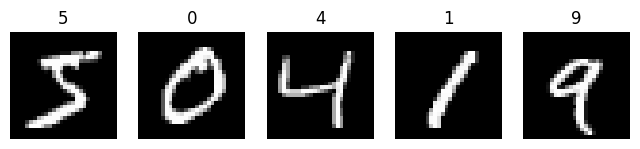

In [2]:
# 1. Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Explore & display sample images
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)
plt.figure(figsize=(8,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

In [3]:
# 2. Preprocess
x_train, x_test = x_train/255.0, x_test/255.0

In [4]:
# 3. Build model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
# 4. Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [6]:
# 5. Train
history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9183 - loss: 0.2895 - val_accuracy: 0.9567 - val_loss: 0.1526
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9622 - loss: 0.1277 - val_accuracy: 0.9615 - val_loss: 0.1271
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9743 - loss: 0.0863 - val_accuracy: 0.9683 - val_loss: 0.1096
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9803 - loss: 0.0656 - val_accuracy: 0.9721 - val_loss: 0.0934
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9845 - loss: 0.0502 - val_accuracy: 0.9735 - val_loss: 0.0870


In [7]:
# 6. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9746 - loss: 0.0815
Test Accuracy: 0.9746000170707703


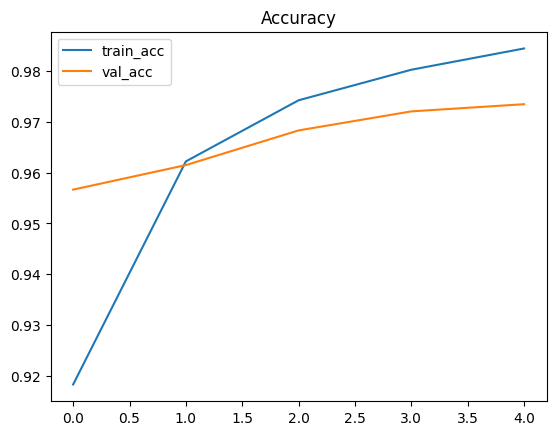

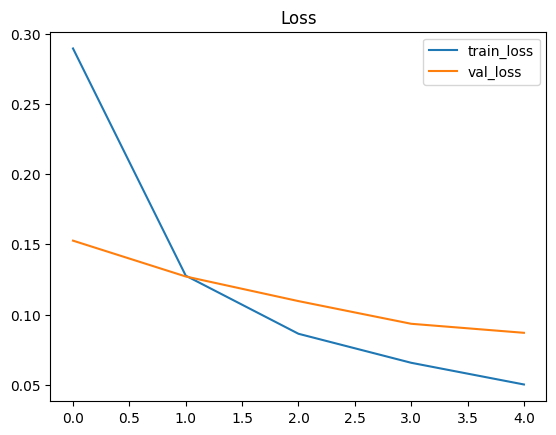

In [8]:
# 7. Plot accuracy & loss
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title("Accuracy"); plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title("Loss"); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


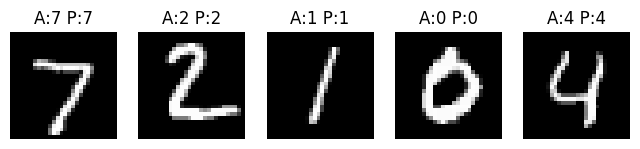

In [9]:
# 8. Test on 5 images
predictions = model.predict(x_test[:5])
plt.figure(figsize=(8,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"A:{y_test[i]} P:{np.argmax(predictions[i])}")
    plt.axis('off')
plt.show()


In [10]:
# 9. Experiment: add Dropout layer
model2 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])
model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model2.fit(x_train, y_train, epochs=5, validation_split=0.2)
test_loss2, test_acc2 = model2.evaluate(x_test, y_test)

print("Baseline Accuracy:", test_acc)
print("With Dropout Accuracy:", test_acc2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9081 - loss: 0.3210 - val_accuracy: 0.9558 - val_loss: 0.1516
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9549 - loss: 0.1557 - val_accuracy: 0.9652 - val_loss: 0.1172
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9641 - loss: 0.1176 - val_accuracy: 0.9698 - val_loss: 0.0997
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9711 - loss: 0.0951 - val_accuracy: 0.9737 - val_loss: 0.0871
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9745 - loss: 0.0795 - val_accuracy: 0.9747 - val_loss: 0.0865
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9768 - loss: 0.0766
Baseline Accuracy: 0.9746000170707703
With Dropout Accuracy: 0.9768000245094299
